# Parameter matching gallery

Repeated plots but tidied up



In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import gaussian_kde
from torch import nn

from nami import (
    RK4,
    LinearParameterPath,
    OracleScore,
    ParameterFlow,
    ScalarPotentialField,
    VPSchedule,
    ctsm_loss,
    parameter_flow_loss,
    path_pinned_parameter_flow_loss,
)
from nami.components import SinusoidalTimeEmbedding
from nami.losses.score_matching import _conditional_time_score, _schedule_rates
 
from pm_utils import p0, p_theta, joint_score, spatial_score, sample_p_theta


### Setup plot style

In [ ]:
INK = "#22223b"
BLUE = "#2274a5"
ACCENT = "#e4572e"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.titleweight": "semibold",
        "axes.labelsize": 13,
        "axes.edgecolor": INK,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": INK,
        "ytick.color": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)

# for saving figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")


torch.manual_seed(7)
generator = torch.Generator().manual_seed(7)

## A family of densities is a flow

The linear-tilt family, given by the following expression:

$$ p_\theta(x) = \mathcal N(x; 0, 1)(1 + \theta\tanh x)$$ 

is a landscape over $(\theta, x)$, with the characteristics of the continuity equation drawn on top. The curves $\dot x = v(x;\theta)$ along which probability mass travels as $\theta$ moves define the velocity field. Transporting a sample from $p_{\theta_0}$ to $p_{\theta_1}$ means riding one of these streamlines. Everything that follows is about learning this velocity, but from scores.

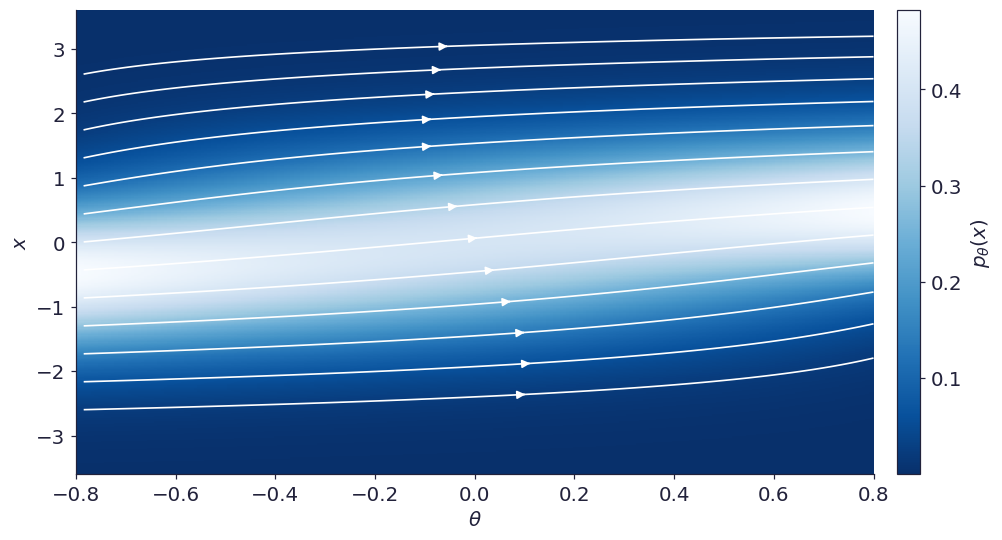

In [33]:

# v(x; theta) = -I(x) / p_theta(x),  I(x) = int p0 tanh
xg_ = torch.linspace(-3.6, 3.6, 401, dtype=torch.float64)
tg_ = torch.linspace(-0.8, 0.8, 241, dtype=torch.float64)

integrand_ = p0(xg_) * torch.tanh(xg_)

I_x_ = torch.cat([torch.zeros(1, dtype=xg_.dtype), torch.cumulative_trapezoid(integrand_, xg_)])
P_ = p_theta(xg_.unsqueeze(-1), tg_)
V_ = (-I_x_.unsqueeze(-1) / P_).numpy()
U_ = np.ones_like(V_)

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
im = ax.pcolormesh(tg_, xg_, P_.numpy(), cmap="Blues_r", shading="auto", rasterized=True)

starts = np.stack(
    [np.full(13, -0.79), np.linspace(-2.6, 2.6, 13)], axis=-1
)

ax.streamplot(
    tg_.numpy(), 
    xg_.numpy(), 
    U_,
    V_,
    start_points=starts, 
    color="w", 
    linewidth=1.1,
    arrowsize=1.1,
    density=10, 
    integration_direction="forward",
)

ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-3.6, 3.6)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$x$")
fig.colorbar(im, ax=ax, label=r"$p_\theta(x)$", pad=0.01)
save(fig, "family-as-flow")
plt.show()

## The PDE residual recovers the velocity

We train the scalar potential $\phi(x,\theta)$ on the elliptic-PDE residual with oracle scores, then compare $\nabla_x\phi$ (dashed) to the analytic continuity-equation velocity (solid).  The shaded ribbons underneath are the densities $p_\theta$. These arethe regions where the match is actually weighted.

In [34]:
field = ScalarPotentialField(1, theta_dim=1, hidden=64, layers=3)
joint = OracleScore(joint_score)
spatial = OracleScore(spatial_score)

In [35]:
opt_ = torch.optim.Adam(field.parameters(), lr=1e-3)
scheduler_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt_, T_max=10_000)


for step in range(3000):
    theta = torch.rand(512, 1, generator=generator) - 0.5
    x = sample_p_theta(theta.squeeze(-1), generator)
    loss = parameter_flow_loss(
        field, x=x, theta=theta, joint_score=joint, spatial_score=spatial
    )
    opt_.zero_grad(); loss.backward(); opt_.step(); scheduler_.step()
    
    if step % 1000 == 0:
        print(f"Step {step}: Loss {loss.item():.3e}: LR {scheduler_.get_last_lr()[0]:.3e}")

print(f"Final loss {loss.item():.3e}")

Step 0: Loss 4.331e-01: LR 1.000e-03
Step 1000: Loss 3.210e-04: LR 9.755e-04
Step 2000: Loss 3.920e-05: LR 9.044e-04
Final loss 1.669e-05


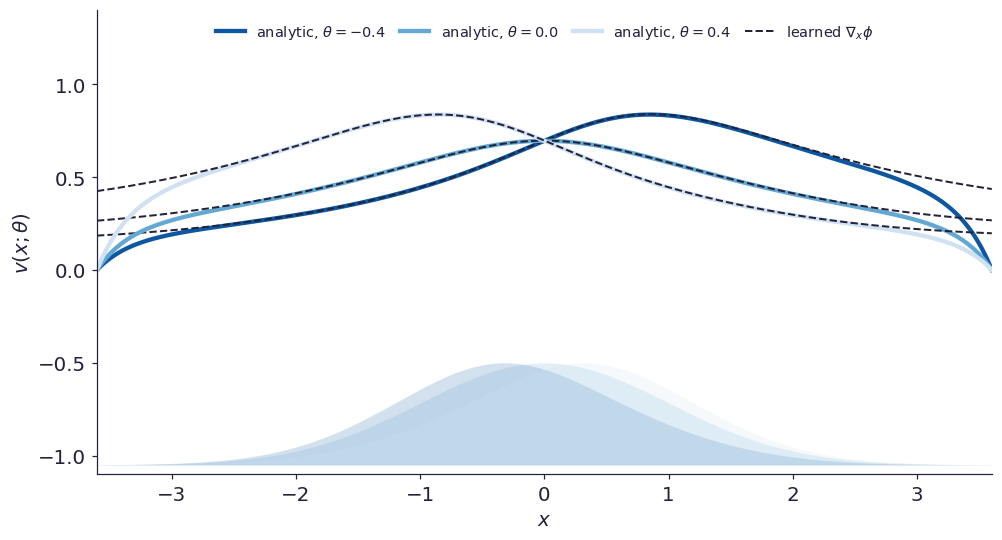

In [36]:
grid = torch.linspace(-3.6, 3.6, 601, dtype=torch.float64)

I_g = torch.cat(
    [torch.zeros(1, dtype=grid.dtype),
     torch.cumulative_trapezoid(p0(grid) * torch.tanh(grid), grid)]
)

thetas_show = (-0.4, 0.0, 0.4)
colors = plt.cm.Blues_r(np.linspace(0.15, 0.8, len(thetas_show)))

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
worst = 0.0
for theta_eval, color in zip(thetas_show, colors):
    th = torch.tensor(theta_eval, dtype=grid.dtype)
    dens = p_theta(grid, th)
    v_true = -I_g / dens
    v_model = (
        field.velocity(grid.float().unsqueeze(-1),
                       torch.full((grid.numel(), 1), theta_eval),
                       create_graph=False)
        .squeeze(-1).double().detach()
    )
    w = dens / torch.trapezoid(dens, grid)
    worst = max(worst, torch.trapezoid((v_model - v_true) ** 2 * w, grid).item())
    ax.fill_between(grid, -1.05, -1.05 + 0.55 * dens / dens.max(),
                    color=color, alpha=0.18, lw=0)
    ax.plot(grid, v_true, color=color, lw=2.8,
            label=rf"analytic, $\theta={theta_eval}$")
    ax.plot(grid, v_model, "--", color=INK, lw=1.3)
ax.plot([], [], "--", color=INK, lw=1.3, label=r"learned $\nabla_x\phi$")
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-1.1, 1.4)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$v(x;\theta)$")


ax.legend(loc="upper center", ncols=4, fontsize=9.5, columnspacing=1.0)

save(fig, "velocity-recovery")
plt.show()

## Transport

We integrate samples of $p_{\theta_0}$ partway along the path and stack the intermediate distributions.  The ridgeline of the transport is the analytic $p_{\theta(s)}$.  Filled curves are kernel-density estimates of the transported samples; the thin dark lines are the analytic $p_{\theta(s)}$ each slice must (and does) land on.

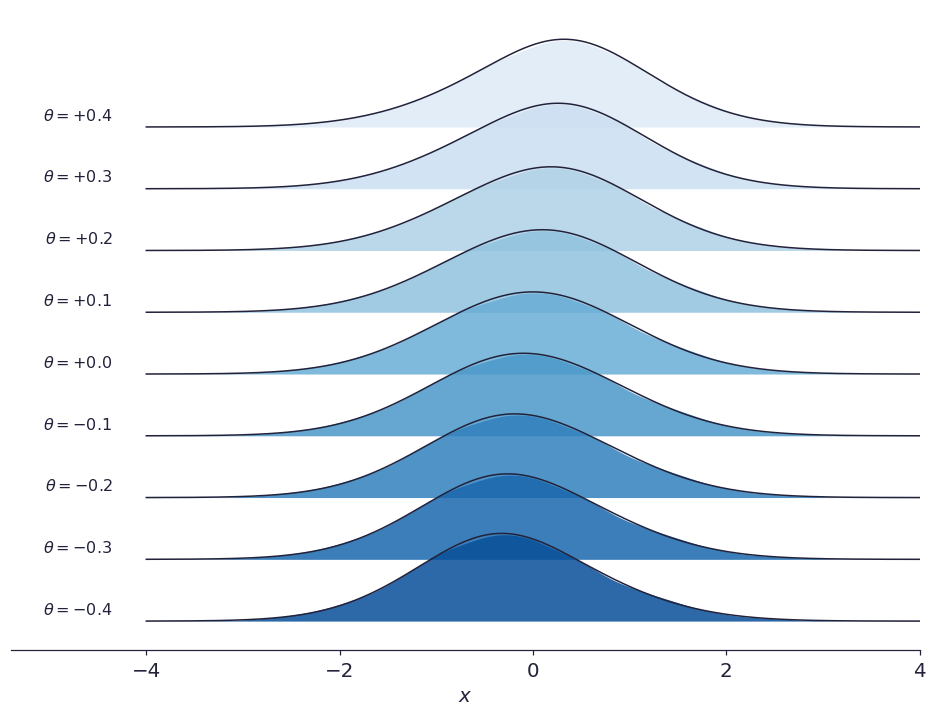

In [37]:
theta_0, theta_1 = -0.4, 0.4

path1d = LinearParameterPath(torch.tensor([theta_0]), torch.tensor([theta_1]))

x0 = sample_p_theta(torch.full((12000,), theta_0), generator)

s_levels = np.linspace(0.0, 1.0, 9)
xs_plot = np.linspace(-4.0, 4.0, 401)
xs_t = torch.tensor(xs_plot)

fig, ax = plt.subplots(figsize=(8.4, 6.4), 
                       layout="constrained",
                       )

offsets = np.arange(len(s_levels)) * 0.30
cmap = plt.cm.Blues_r

for i, (s, off) in enumerate(zip(s_levels, offsets)):
    if s == 0.0:
        xs_now = x0
    else:
        proc = ParameterFlow(field, RK4(steps=48), s1=float(s))(path1d)
        with torch.no_grad():
            xs_now = proc.transport(x0)
    kde = gaussian_kde(xs_now.squeeze(-1).numpy(), bw_method=0.18)
    dens = kde(xs_plot)
    th_s = theta_0 + s * (theta_1 - theta_0)
    truth = p_theta(xs_t, torch.tensor(th_s)).numpy()
    color = cmap(0.12 + 0.75 * s)
    ax.fill_between(xs_plot, off, off + dens, color=color, alpha=0.85,
                    lw=0, zorder=10 - i)
    ax.plot(xs_plot, off + truth, color=INK, lw=1.0, zorder=10 - i + 0.5)
    ax.text(-4.35, off + 0.02, rf"$\theta={th_s:+.1f}$",
            fontsize=10.5, ha="right", va="bottom", color=INK)

ax.set_xlim(-5.4, 4.0)
ax.set_yticks([])
ax.set_xlabel(r"$x$")
ax.spines["left"].set_visible(False)
save(fig, "transport-ridgeline")
plt.show()

## Multi-parameter trajectories

Here, we look at one scalar potential and another pinned diagonal path $\theta(s) = (1-s)\,(0,0) + s\,(1,1)$ for $\mathcal N(\theta, I)$.  Each streak is one sample riding $\dot x = \nabla_x\phi$ from the start cloud to the target; colour encodes path time $s$. 

Dashed circles are the $1\sigma$ and $2\sigma$ contours of the analytic endpoint densities.

In [38]:
torch.manual_seed(11)
gen2 = torch.Generator().manual_seed(11)
th0 = torch.tensor([0.0, 0.0])
th1 = torch.tensor([1.0, 1.0])
path2d = LinearParameterPath(th0, th1)

field2_ = ScalarPotentialField(2, theta_dim=2, hidden=64, layers=3)
opt2_ = torch.optim.Adam(field2_.parameters(), lr=1e-3)
scheduler2_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt2_, T_max=3000)
for step in range(3000):
    s = torch.rand(512, generator=gen2)
    theta_s = path2d.theta(s)
    x = theta_s + torch.randn(512, 2, generator=gen2)
    loss = path_pinned_parameter_flow_loss(
        field2_, x=x, s=s, path=path2d,
        joint_score=OracleScore(lambda x, th: x - th),
        spatial_score=OracleScore(lambda x, th: th - x),
    )
    opt2_.zero_grad(); loss.backward(); opt2_.step(); scheduler2_.step()
    if step % 1000 == 0:
        print(f"Step {step}: Loss {loss.item():.3e}: LR {scheduler2_.get_last_lr()[0]:.3e}")
print(f"Final loss {loss.item():.3e}")

Step 0: Loss 1.945e+00: LR 1.000e-03
Step 1000: Loss 4.059e-06: LR 7.495e-04
Step 2000: Loss 1.711e-06: LR 2.495e-04
Final loss 1.748e-06


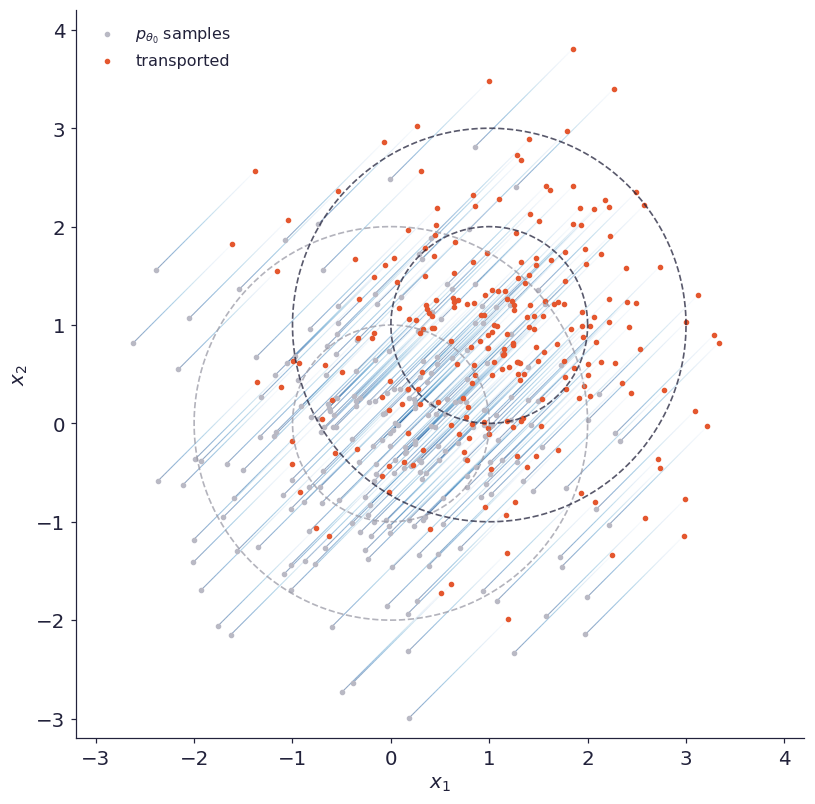

In [39]:
n_traj, n_steps = 240, 64
x = th0 + torch.randn(n_traj, 2, generator=gen2)
traj = [x.clone()]
h = 1.0 / n_steps


def v_at(xi, s):
    # velocity() needs autograd for grad-phi
    th = path2d.theta(torch.full((xi.shape[0],), s))
    return field2_.velocity(xi, th, create_graph=False).detach()


for k in range(n_steps):
    s_k = k * h
    k1 = v_at(x, s_k)
    k2 = v_at(x + 0.5 * h * k1, s_k + 0.5 * h)
    k3 = v_at(x + 0.5 * h * k2, s_k + 0.5 * h)
    k4 = v_at(x + h * k3, s_k + h)
    x = x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    traj.append(x.clone())
traj = torch.stack(traj).numpy()


fig, ax = plt.subplots(figsize=(7.6, 7.2), layout="constrained")
cmap = plt.cm.Blues_r
for k in range(n_steps):
    segs = np.stack([traj[k], traj[k + 1]], axis=1)
    ax.add_collection(
        LineCollection(segs, colors=[cmap(k / n_steps)], lw=0.7, alpha=0.45)
    )
    
ax.scatter(*traj[0].T, s=7, color="#b9b9c4", zorder=3, label=r"$p_{\theta_0}$ samples")
ax.scatter(*traj[-1].T, s=7, color=ACCENT, zorder=4, label="transported")
angles = np.linspace(0, 2 * np.pi, 200)
for centre, color in ((th0.numpy(), "#9a9aa6"), (th1.numpy(), INK)):
    for r in (1.0, 2.0):
        ax.plot(centre[0] + r * np.cos(angles), centre[1] + r * np.sin(angles),
                "--", color=color, lw=1.1, alpha=0.75, zorder=5)
ax.set_aspect("equal")
ax.set_xlim(-3.2, 4.2)
ax.set_ylim(-3.2, 4.2)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(loc="upper left", fontsize=10.5)
save(fig, "trajectories")
plt.show()

## The denoising trick via CTSM

When no closed-form score exists, we can make use of the CTSM formalism that learns the time score $\partial_t \log p_t(x)$ from samples alone. Each grey dot is one $(z, \varepsilon)$ pair's conditional target (individually wild, hundreds of percent off!). But, their conditional mean at each $x$ sits exactly on the analytic marginal time score. Squared-error regression
converges to that mean (Theorem 1 of the paper).

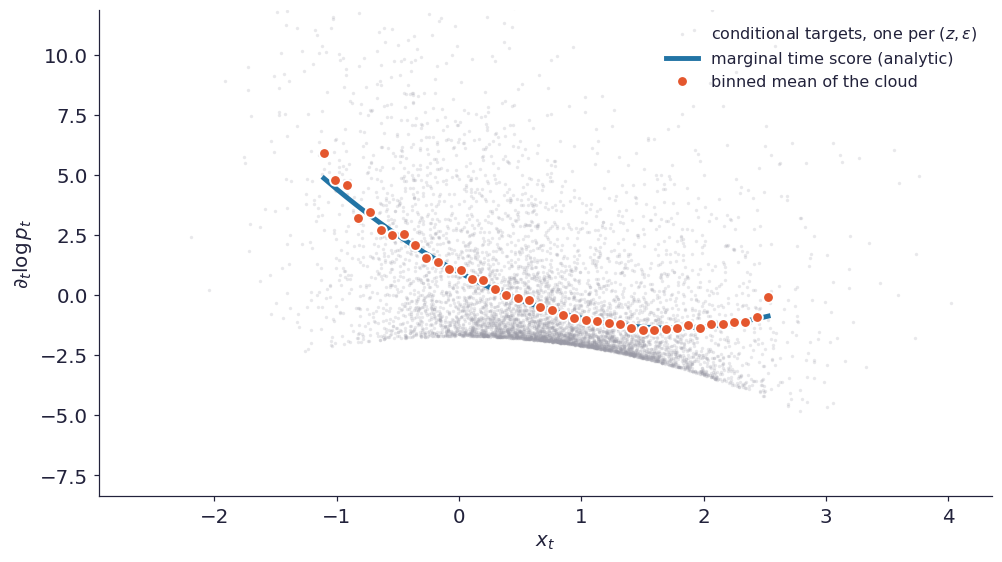

In [40]:
torch.manual_seed(11)
gen3 = torch.Generator().manual_seed(11)
schedule = VPSchedule(0.1, 8.0)
MU1, SIG1 = 1.0, 0.7


def marginal_logp(x, t):
    a, s = schedule.alpha(t), schedule.sigma(t)
    v = a**2 * SIG1**2 + s**2
    return (
        -0.5 * math.log(2 * math.pi) - 0.5 * torch.log(v)
        - (x - a * MU1) ** 2 / (2 * v)
    )


def marginal_time_score(x, t):
    t = t.detach().clone().requires_grad_(True)
    (g,) = torch.autograd.grad(marginal_logp(x, t).sum(), t)
    return g


t_show, n = 0.4, 20000
z = MU1 + SIG1 * torch.randn(n, 1, generator=gen3)
eps = torch.randn(n, 1, generator=gen3)
tt = torch.full((n,), t_show)
a, s, a_dot, s_dot = _schedule_rates(schedule, tt)
x_t = (a.unsqueeze(-1) * z + s.unsqueeze(-1) * eps).squeeze(-1)
cond_target = _conditional_time_score(z, eps, a_dot, s, s_dot)

edges = torch.linspace(x_t.quantile(0.015), x_t.quantile(0.985), 41)
centres = 0.5 * (edges[:-1] + edges[1:])
idx = torch.bucketize(x_t, edges).clamp(1, len(edges) - 1) - 1
binned = torch.full_like(centres, torch.nan)
for b in range(len(centres)):
    sel = idx == b
    if sel.sum() > 50:
        binned[b] = cond_target[sel].mean()

xs = torch.linspace(centres[0], centres[-1], 201)
truth = marginal_time_score(xs, torch.full_like(xs, t_show))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.scatter(x_t[:6000], cond_target[:6000], s=5, alpha=0.22, color="#9a9aa6",
           lw=0, label=r"conditional targets, one per $(z,\varepsilon)$")
ax.plot(xs, truth, lw=3.2, color=BLUE, label="marginal time score (analytic)",
        zorder=3)
ax.plot(centres, binned, "o", ms=7, color=ACCENT, mec="w", mew=1.2,
        label="binned mean of the cloud", zorder=4)
ax.set_xlabel(r"$x_t$")
ax.set_ylabel(r"$\partial_t \log p_t$")
ax.set_ylim(float(truth.min()) - 7, float(truth.max()) + 7)
ax.legend(loc="upper right", fontsize=10.5)
save(fig, "denoising-trick")
plt.show()

## The time-score surface

Now, we train $s_\phi(x,t)$ with `ctsm_loss` (samples in, no oracle anywhere), then show the entire learned surface over $(t, x)$, with the analytic marginal time score as black contour lines. Where the contours track the colour boundaries, the network is right, which is everywhere the path carries mass.

In [41]:
t_emb = SinusoidalTimeEmbedding(16, max_period=100.0)
net = nn.Sequential(
    nn.Linear(1 + 16, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 1),
)


def s_phi(x, t):
    feats = t_emb(t, leading_shape=x.shape[:-1], device=x.device, dtype=x.dtype)
    return net(torch.cat([x, feats], dim=-1))


opt3_ = torch.optim.Adam(net.parameters(), lr=1e-3)
sched3_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt3_, T_max=8000, eta_min=1e-5)
for step in range(8000):
    z = MU1 + SIG1 * torch.randn(4096, 1, generator=gen3)
    loss = ctsm_loss(s_phi, x_data=z, schedule=schedule, eps_t=0.05)
    opt3_.zero_grad(); loss.backward(); opt3_.step(); sched3_.step()
    if step % 2000 == 0:
        print(f"CTSM step {step}: loss {loss.item():.3f} lr {sched3_.get_last_lr()[0]:.3e}")
print(f"CTSM Final loss {loss.item():.3f}")

CTSM step 0: loss 1.023 lr 1.000e-03
CTSM step 2000: loss 0.752 lr 8.549e-04
CTSM step 4000: loss 0.608 lr 5.048e-04
CTSM step 6000: loss 0.642 lr 1.548e-04
CTSM Final loss 0.693


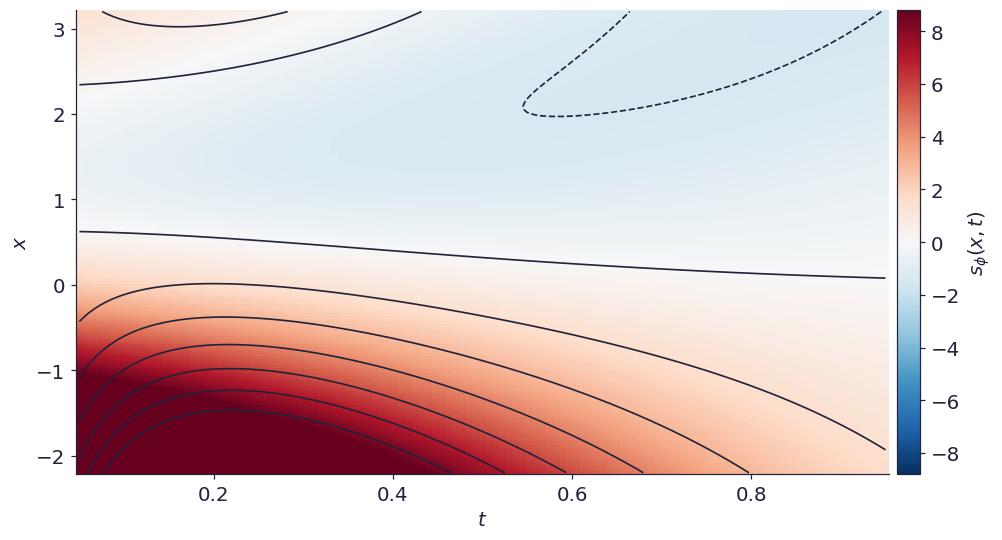

In [42]:
t_axis = torch.linspace(0.05, 0.95, 121)
x_axis = torch.linspace(-2.2, 3.2, 161)
with torch.no_grad():
    pred = torch.stack(
        [s_phi(x_axis.unsqueeze(-1), torch.full_like(x_axis, t)).squeeze(-1)
         for t in t_axis.tolist()]
    ).T                                            # (x, t)
truth_surf = torch.stack(
    [marginal_time_score(x_axis, torch.full_like(x_axis, t))
     for t in t_axis.tolist()]
).T

lim = float(truth_surf.abs().quantile(0.96))
levels = np.linspace(-lim, lim, 13)

# per-t weighted RMS at the milestone evaluation times
pct = []
for t_eval in (0.25, 0.5, 0.75):
    tt_e = torch.full_like(x_axis, t_eval)
    with torch.no_grad():
        p_line = s_phi(x_axis.unsqueeze(-1), tt_e).squeeze(-1)
    t_line = marginal_time_score(x_axis, tt_e)
    w = torch.exp(marginal_logp(x_axis, tt_e))
    w = w / w.sum()
    rms = ((p_line - t_line).pow(2) * w).sum().sqrt()
    pct.append(float(100 * rms / (t_line.pow(2) * w).sum().sqrt()))

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
im = ax.pcolormesh(t_axis, x_axis, pred, cmap="RdBu_r",
                   norm=TwoSlopeNorm(0.0, -lim, lim), shading="auto",
                   rasterized=True)
ax.contour(t_axis, x_axis, truth_surf, levels=levels, colors=INK,
           linewidths=1.1)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
fig.colorbar(im, ax=ax, label=r"$s_\phi(x,t)$", pad=0.01)
save(fig, "ctsm-surface")
plt.show()

Note: not perfect converged, but close.

## Integrate the network to get density ratios

The trained time score is a continuum of density ratios:

$$\log\bigl[p_{t_1}(x)/p_{t_0}(x)\bigr] = \int_{t_0}^{t_1} s_\phi(x,\tau)\,d\tau$$

On a parameter path this identity turns the learned score into per-event likelihood information. This provides the bridge from CTSM to inference.

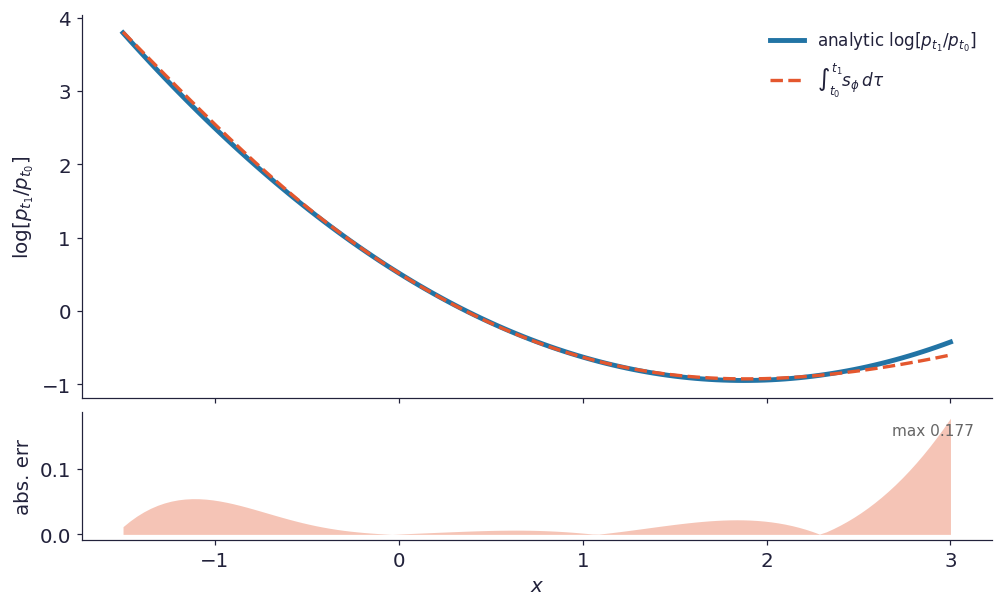

In [43]:
t0, t1 = 0.15, 0.9
taus = torch.linspace(t0, t1, 201)
xs = torch.linspace(-1.5, 3.0, 121)
with torch.no_grad():
    grid_pred = torch.stack(
        [s_phi(xs.unsqueeze(-1), torch.full_like(xs, t)).squeeze(-1)
         for t in taus.tolist()]
    )
integral = torch.trapezoid(grid_pred, taus, dim=0)
truth_lr = marginal_logp(xs, torch.full_like(xs, t1)) - marginal_logp(
    xs, torch.full_like(xs, t0)
)

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(9, 5.4), height_ratios=[3, 1], sharex=True,
    layout="constrained",
)
ax.plot(xs, truth_lr, lw=3.2, color=BLUE,
        label=r"analytic $\log[p_{t_1}/p_{t_0}]$")
ax.plot(xs, integral, "--", lw=2.2, color=ACCENT,
        label=r"$\int_{t_0}^{t_1} s_\phi\,d\tau$")
ax.set_ylabel(r"$\log[p_{t_1}/p_{t_0}]$")
ax.legend(fontsize=11)

err = (integral - truth_lr).abs()
axr.fill_between(xs, 0, err, color=ACCENT, alpha=0.35, lw=0)
axr.set_ylabel("abs. err")
axr.set_xlabel(r"$x$")
axr.text(0.98, 0.82, f"max {err.max():.3f}", transform=axr.transAxes,
         ha="right", fontsize=10, color="#666")
save(fig, "ctsm-density-ratio")
plt.show()